## 주제 선정


조금 늦었지만 코로나는 여전히 변형되는 형태로 감염되어 흥미로운 주제가 될 수 있다고 생각해 과거의 코로나 데이터 분석

In [8]:
import sys
print(sys.version)

3.11.2 (tags/v3.11.2:878ead1, Feb  7 2023, 16:38:35) [MSC v.1934 64 bit (AMD64)]


In [9]:
!pip install seaborn


[notice] A new release of pip available: 22.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### 데이터 수집

In [3]:
# COVID-19 데이터 수집 (Python)
import os
import pandas as pd

url = "https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_global.csv"
# 데이터 읽기
covid_data = pd.read_csv(url)

# 상위 폴더의 data 폴더 경로
data_folder_path = '../data'

# data 폴더 생성 (존재하지 않는 경우)
if not os.path.exists(data_folder_path):
    os.makedirs(data_folder_path)

# 데이터 저장
covid_data.to_csv(os.path.join(data_folder_path, 'data.csv'), index=False)

### EDA

In [5]:
# 결측치 확인
print(covid_data.isnull().sum())

# 국가별 총 확진자 수 계산
covid_data['Total'] = covid_data.iloc[:, 4:].sum(axis=1)
top_countries = covid_data[['Country/Region', 'Total']].groupby('Country/Region').sum().nlargest(10, 'Total')

Province/State    198
Country/Region      0
Lat                 2
Long                2
1/22/20             0
                 ... 
3/5/23              0
3/6/23              0
3/7/23              0
3/8/23              0
3/9/23              0
Length: 1147, dtype: int64


### 시각화

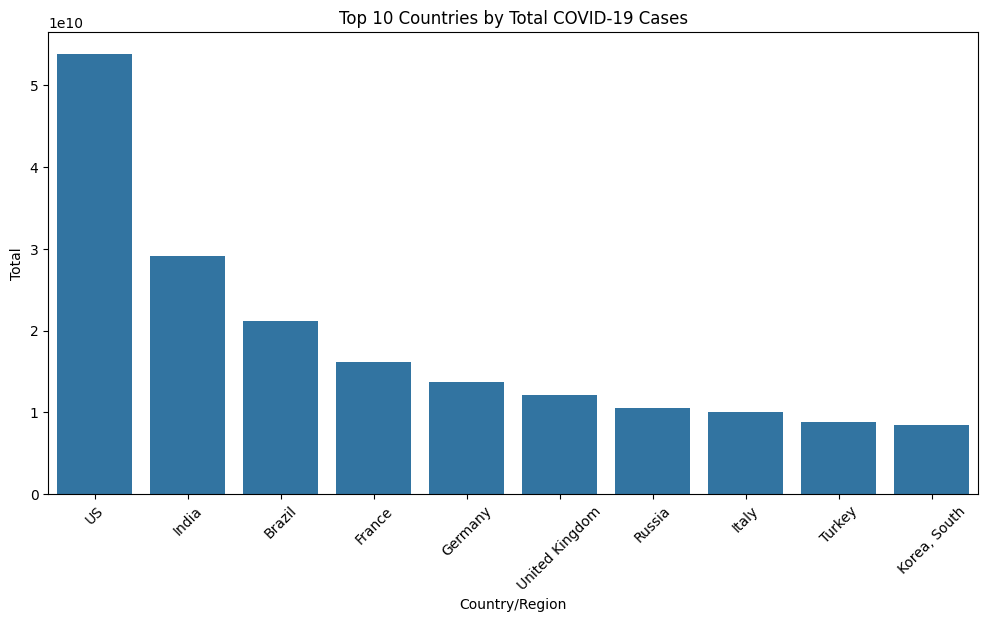

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x=top_countries.index, y=top_countries['Total'])
plt.title('Top 10 Countries by Total COVID-19 Cases')
plt.xticks(rotation=45)

# 상위 폴더의 visuals 폴더 경로
visuals_folder_path = '../visuals'

# visuals 폴더 생성 (존재하지 않는 경우)
if not os.path.exists(visuals_folder_path):
    os.makedirs(visuals_folder_path)

# 그래프 저장
plt.savefig(os.path.join(visuals_folder_path, 'top10.png'), bbox_inches='tight')

# 그래프 보여주기
plt.show()